# Introduction

## Project Background

Laptop merupakan salah satu perangkat penting yang digunakan untuk berbagai kebutuhan, seperti belajar, bekerja, produktivitas, desain, hiburan, hingga gaming. Namun, banyaknya pilihan laptop dengan spesifikasi yang berbeda sering membuat user kesulitan menentukan laptop yang paling sesuai.

Dalam praktiknya, user sering mengetahui kebutuhan mereka secara umum, misalnya laptop untuk kuliah, kerja, penggunaan harian, atau gaming ringan. Akan tetapi, user belum tentu memahami detail teknis seperti CPU, GPU, RAM, storage, tipe laptop, ukuran layar, berat, sistem operasi, dan harga. Kondisi ini dapat membuat proses pemilihan laptop menjadi kurang efektif dan berisiko menghasilkan pilihan yang tidak sesuai dengan kebutuhan maupun budget user.

## Problem Statement

Permasalahan utama dalam project ini adalah bagaimana membantu user memilih laptop yang sesuai ketika kebutuhan user masih bersifat umum atau abstrak, sementara informasi produk laptop disajikan dalam bentuk spesifikasi teknis.

Tanpa sistem rekomendasi, user perlu membandingkan banyak produk secara manual berdasarkan brand, tipe, RAM, CPU, GPU, storage, ukuran layar, berat, sistem operasi, dan harga. Proses ini dapat membingungkan, terutama bagi user yang belum memahami hubungan antara spesifikasi laptop dengan kebutuhan penggunaan sehari-hari.

## Objective

Project ini bertujuan membangun sistem rekomendasi laptop yang membantu user memilih laptop sesuai kebutuhan, budget, dan spesifikasi, terutama ketika user belum memahami detail teknis seperti CPU, GPU, RAM, storage, atau tipe laptop.

## Method Overview

Metode yang digunakan adalah content-based filtering dengan cosine similarity. Content-based filtering digunakan untuk memberikan rekomendasi berdasarkan kemiripan karakteristik antarproduk.

Dalam project ini, sistem akan membandingkan karakteristik laptop seperti brand, tipe, RAM, CPU, GPU, storage, ukuran layar, berat, sistem operasi, dan harga. Cosine similarity digunakan untuk mengukur tingkat kemiripan antar laptop berdasarkan fitur-fitur tersebut. Laptop dengan nilai similarity tertinggi akan ditampilkan sebagai rekomendasi yang paling relevan.

## Expected Output

Dengan pendekatan ini, sistem dapat membantu user menemukan laptop yang lebih relevan dengan kebutuhan dan budget mereka. Selain itu, sistem ini juga dapat mendukung bisnis atau marketplace dalam memberikan rekomendasi produk yang lebih tepat sasaran, sehingga pengalaman pencarian produk menjadi lebih mudah, dan cepat

# Import Libraries

In [19]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [20]:
# Load the dataset
df = pd.read_csv('laptop_price.csv', encoding='latin1')

# Display the first 5 rows
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [21]:
# Check dataset shape
df.shape

(1303, 13)

In [ ]:
# Display column names
df.columns.tolist()

['laptop_ID',
 'Company',
 'Product',
 'TypeName',
 'Inches',
 'ScreenResolution',
 'Cpu',
 'Ram',
 'Memory',
 'Gpu',
 'OpSys',
 'Weight',
 'Price_euros']

# Data Understanding

In [23]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [24]:
# Display descriptive statistics for numerical columns
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [25]:
# Display descriptive statistics for categorical columns
df.describe(include='object')

,Company,Product,TypeName,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
count,1303,1303,1303,1303,1303,1303,1303,1303,1303,1303
unique,19,618,6,40,118,9,39,110,9,179
top,Dell,XPS 13,Notebook,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg
freq,297,30,727,507,190,619,412,281,1072,121


In [26]:
# Check number of unique values in each column
df.nunique().sort_values(ascending=False)

laptop_ID           1303
Price_euros          791
Product              618
Weight               179
Cpu                  118
Gpu                  110
ScreenResolution      40
Memory                39
Company               19
Inches                18
Ram                    9
OpSys                  9
TypeName               6
dtype: int64

In [27]:
# Check missing values in each column
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [28]:
# Check duplicate rows
df.duplicated().sum()

0

# Exploratory Data Analysis

## Price Distribution Analysis

In [29]:
# Display descriptive statistics for laptop price
df['Price_euros'].describe()

count    1303.000000
mean     1123.686992
std       699.009043
min       174.000000
25%       599.000000
50%       977.000000
75%      1487.880000
max      6099.000000
Name: Price_euros, dtype: float64

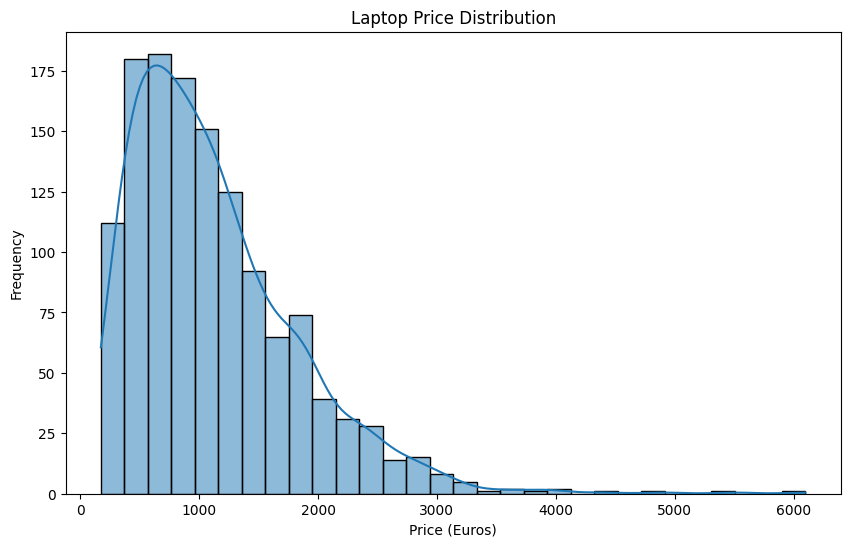

In [30]:
# Visualize laptop price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Price_euros'], bins=30, kde=True)
plt.title('Laptop Price Distribution')
plt.xlabel('Price (Euros)')
plt.ylabel('Frequency')
plt.show()

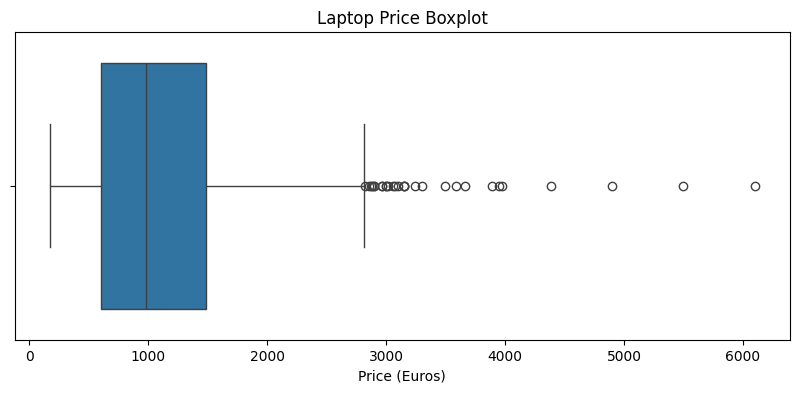

In [31]:
# Visualize price outliers using boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Price_euros'])
plt.title('Laptop Price Boxplot')
plt.xlabel('Price (Euros)')
plt.show()

## Brand Analysis

In [32]:
# Count laptops by brand
df['Company'].value_counts()

Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: Company, dtype: int64

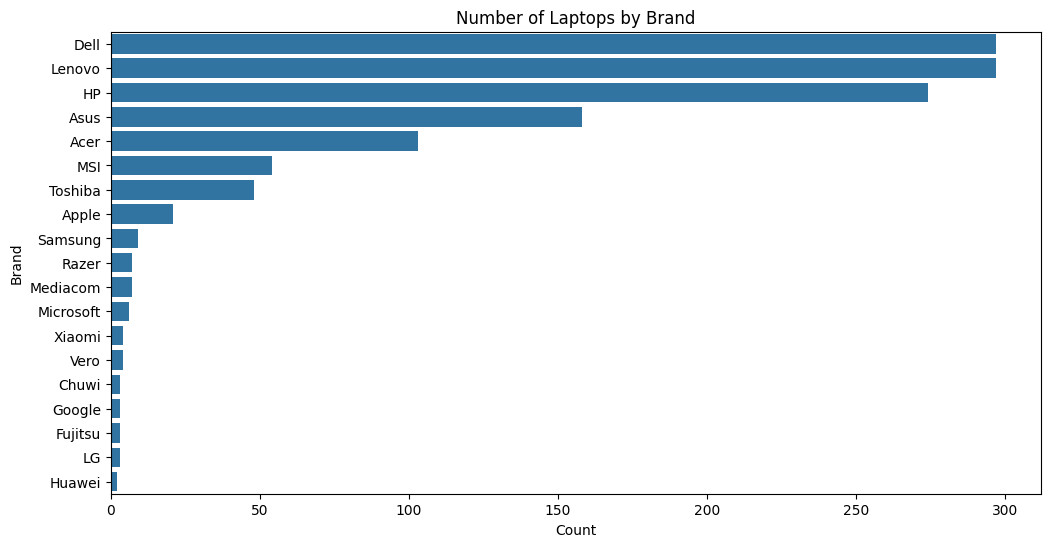

In [33]:
# Visualize number of laptops by brand
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Company', order=df['Company'].value_counts().index)
plt.title('Number of Laptops by Brand')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.show()

In [34]:
# Average price by brand
brand_price = df.groupby('Company')['Price_euros'].mean().sort_values(ascending=False)

brand_price

Company
Razer        3346.142857
LG           2099.000000
MSI          1728.908148
Google       1677.666667
Microsoft    1612.308333
Apple        1564.198571
Huawei       1424.000000
Samsung      1413.444444
Toshiba      1267.812500
Dell         1186.068990
Xiaomi       1133.462500
Asus         1104.169367
Lenovo       1086.384444
HP           1067.774854
Fujitsu       729.000000
Acer          626.775825
Chuwi         314.296667
Mediacom      295.000000
Vero          217.425000
Name: Price_euros, dtype: float64

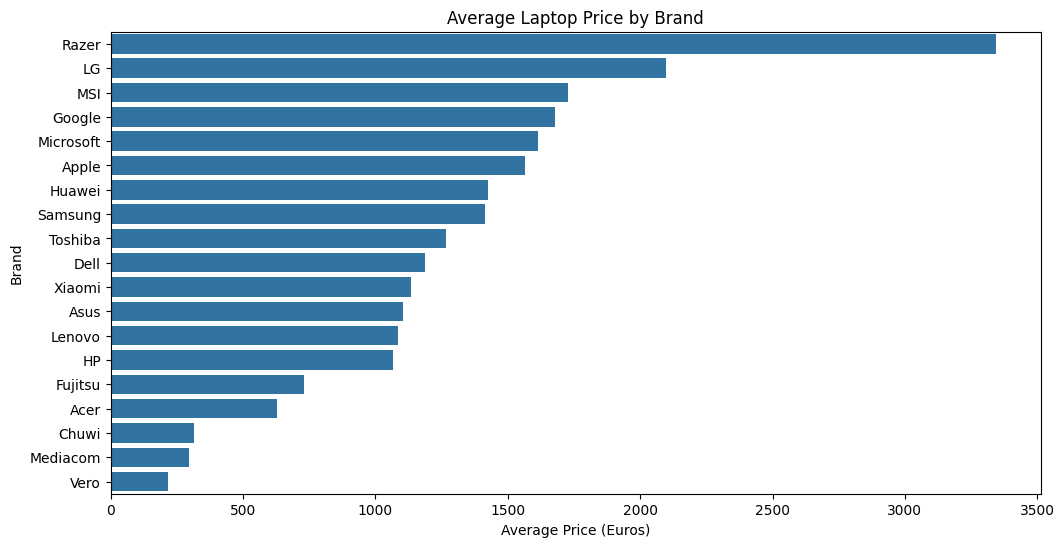

In [35]:
# Visualize average price by brand
plt.figure(figsize=(12, 6))
sns.barplot(x=brand_price.values, y=brand_price.index)
plt.title('Average Laptop Price by Brand')
plt.xlabel('Average Price (Euros)')
plt.ylabel('Brand')
plt.show()

## Laptop Type Analysis

In [36]:
# Count laptops by type
df['TypeName'].value_counts()

Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: TypeName, dtype: int64

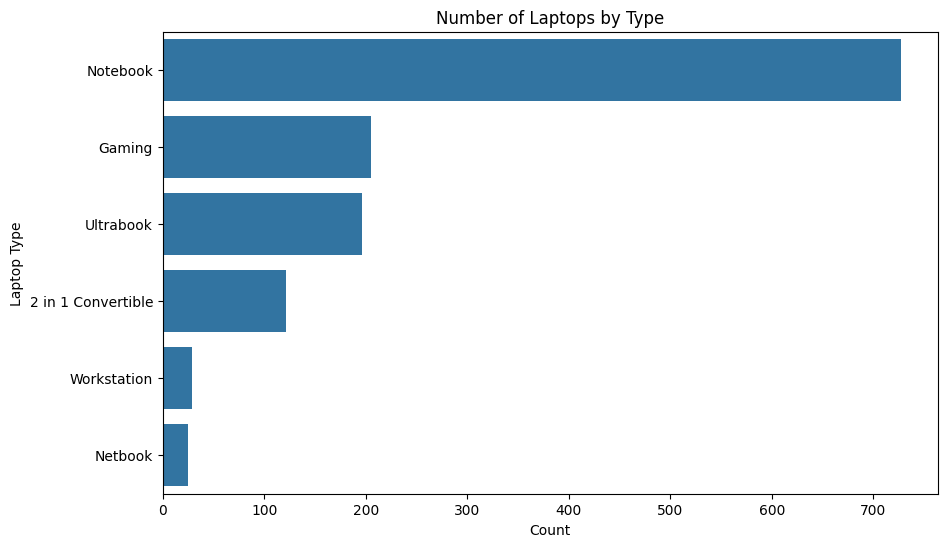

In [37]:
# Visualize number of laptops by type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='TypeName', order=df['TypeName'].value_counts().index)
plt.title('Number of Laptops by Type')
plt.xlabel('Count')
plt.ylabel('Laptop Type')
plt.show()

In [38]:
# Average price by laptop type
type_price = df.groupby('TypeName')['Price_euros'].mean().sort_values(ascending=False)

type_price

TypeName
Workstation           2280.358966
Gaming                1731.380634
Ultrabook             1548.230357
2 in 1 Convertible    1282.401653
Notebook               782.078624
Netbook                636.232000
Name: Price_euros, dtype: float64

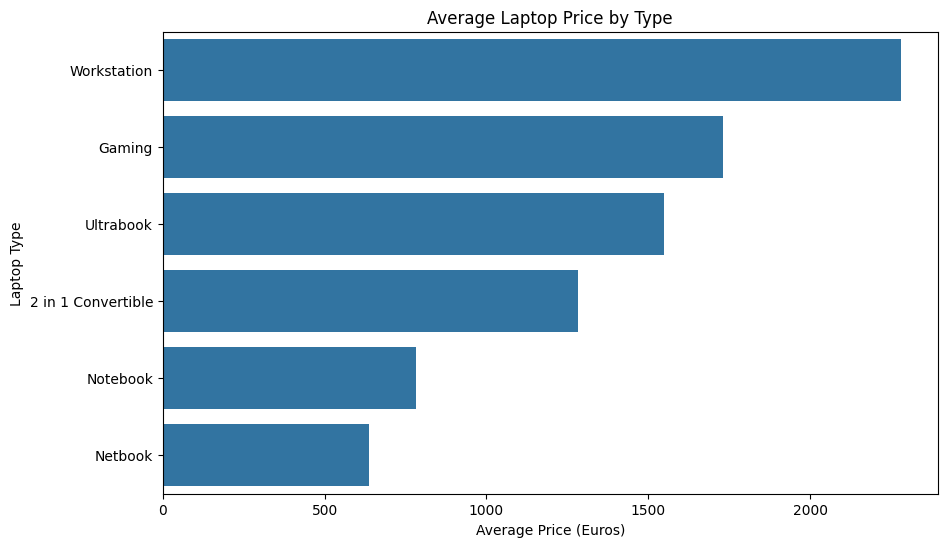

In [39]:
# Visualize average price by laptop type
plt.figure(figsize=(10, 6))
sns.barplot(x=type_price.values, y=type_price.index)
plt.title('Average Laptop Price by Type')
plt.xlabel('Average Price (Euros)')
plt.ylabel('Laptop Type')
plt.show()

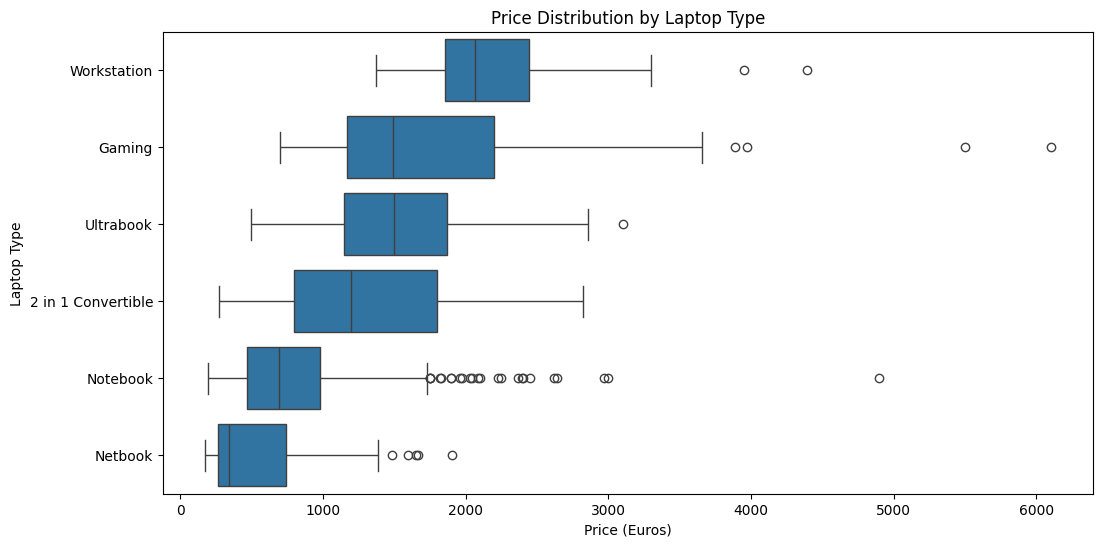

In [40]:
# Visualize price distribution by laptop type
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Price_euros', y='TypeName', order=type_price.index)
plt.title('Price Distribution by Laptop Type')
plt.xlabel('Price (Euros)')
plt.ylabel('Laptop Type')
plt.show()

## RAM Analysis

In [41]:
# Create RAM column in numeric format
df['Ram_GB'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)

# Count laptops by RAM capacity
df['Ram_GB'].value_counts().sort_index()

2      22
4     375
6      41
8     619
12     25
16    200
24      3
32     17
64      1
Name: Ram_GB, dtype: int64

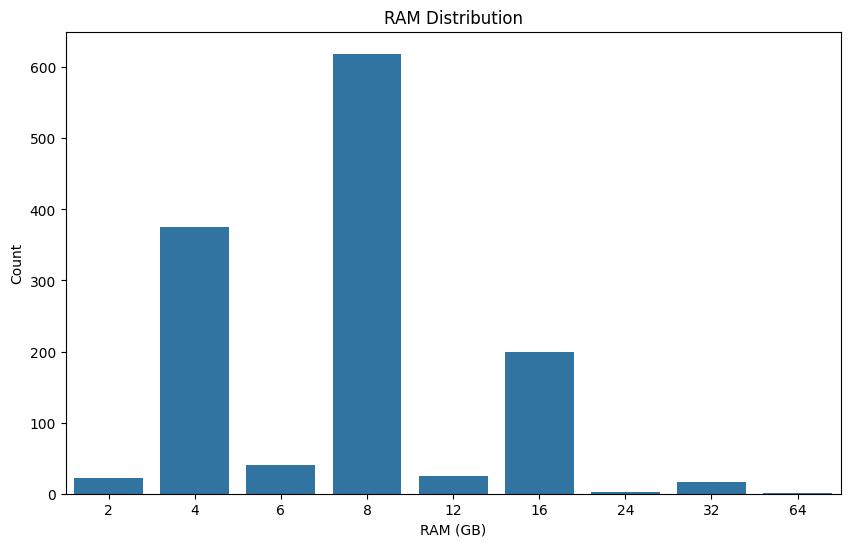

In [42]:
# Visualize RAM distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Ram_GB', order=sorted(df['Ram_GB'].unique()))
plt.title('RAM Distribution')
plt.xlabel('RAM (GB)')
plt.ylabel('Count')
plt.show()

In [43]:
# Average price by RAM capacity
ram_price = df.groupby('Ram_GB')['Price_euros'].mean().sort_index()

ram_price

Ram_GB
2      254.370455
4      574.572480
6      615.206341
8     1180.812940
12    1239.438400
16    1936.771150
24    2206.333333
32    3413.085882
64    3975.000000
Name: Price_euros, dtype: float64

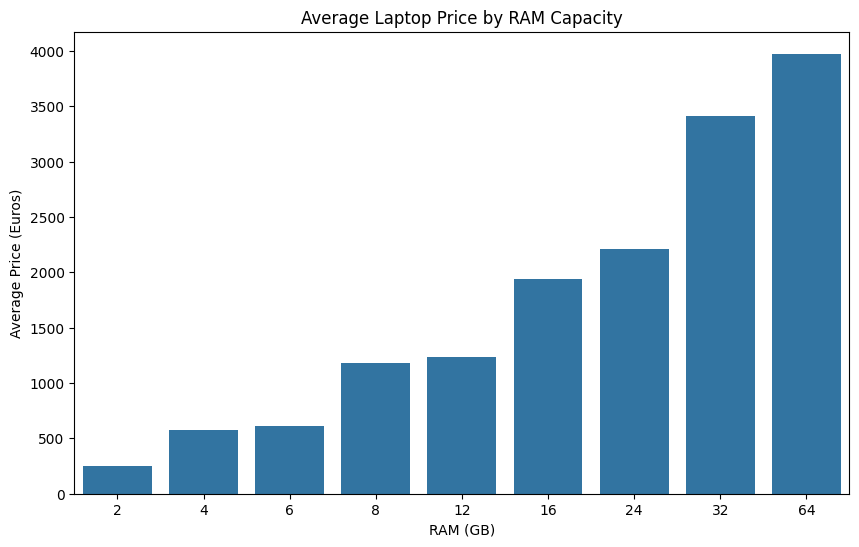

In [44]:
# Visualize average price by RAM capacity
plt.figure(figsize=(10, 6))
sns.barplot(x=ram_price.index, y=ram_price.values)
plt.title('Average Laptop Price by RAM Capacity')
plt.xlabel('RAM (GB)')
plt.ylabel('Average Price (Euros)')
plt.show()

## CPU Analysis

In [45]:
# Create CPU category
def get_cpu_category(cpu):
    if 'Core i7' in cpu:
        return 'Intel Core i7'
    elif 'Core i5' in cpu:
        return 'Intel Core i5'
    elif 'Core i3' in cpu:
        return 'Intel Core i3'
    elif 'Core M' in cpu:
        return 'Intel Core M'
    elif 'Celeron' in cpu:
        return 'Intel Celeron'
    elif 'Pentium' in cpu:
        return 'Intel Pentium'
    elif 'Ryzen' in cpu:
        return 'AMD Ryzen'
    elif 'A-Series' in cpu:
        return 'AMD A-Series'
    elif 'E-Series' in cpu:
        return 'AMD E-Series'
    elif 'FX' in cpu:
        return 'AMD FX'
    else:
        return 'Other'

df['Cpu_Category'] = df['Cpu'].apply(get_cpu_category)

# Count CPU category
df['Cpu_Category'].value_counts()

Intel Core i7    527
Intel Core i5    423
Intel Core i3    136
Intel Celeron     88
Other             65
Intel Pentium     30
Intel Core M      19
AMD E-Series       9
AMD Ryzen          4
AMD FX             2
Name: Cpu_Category, dtype: int64

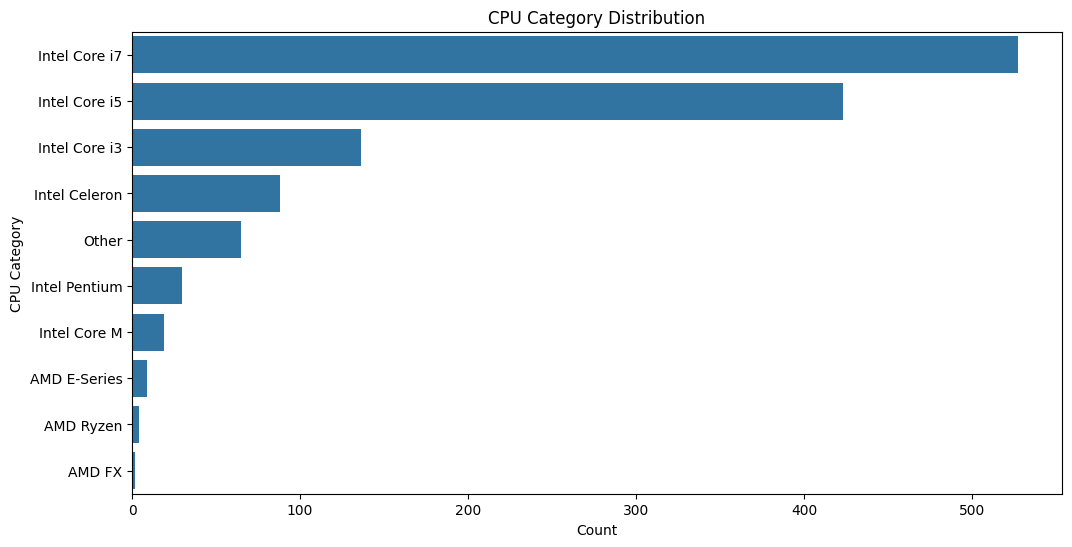

In [46]:
# Visualize CPU category distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Cpu_Category', order=df['Cpu_Category'].value_counts().index)
plt.title('CPU Category Distribution')
plt.xlabel('Count')
plt.ylabel('CPU Category')
plt.show()

In [47]:
# Average price by CPU category
cpu_price = df.groupby('Cpu_Category')['Price_euros'].mean().sort_values(ascending=False)

cpu_price

Cpu_Category
AMD Ryzen        1685.500000
Intel Core i7    1595.779108
Intel Core M     1324.231579
Intel Core i5    1015.015248
AMD FX            849.000000
Other             656.930462
Intel Core i3     541.625956
Intel Pentium     435.540000
Intel Celeron     319.328523
AMD E-Series      300.887778
Name: Price_euros, dtype: float64

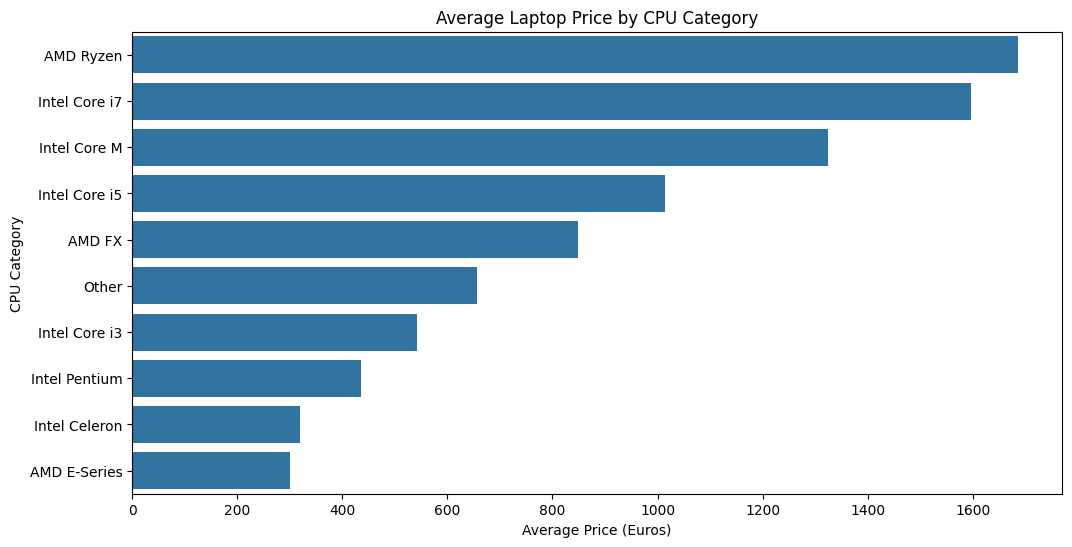

In [48]:
# Visualize average price by CPU category
plt.figure(figsize=(12, 6))
sns.barplot(x=cpu_price.values, y=cpu_price.index)
plt.title('Average Laptop Price by CPU Category')
plt.xlabel('Average Price (Euros)')
plt.ylabel('CPU Category')
plt.show()

## GPU Analysis

In [49]:
# Create GPU brand
def get_gpu_brand(gpu):
    if 'Nvidia' in gpu:
        return 'Nvidia'
    elif 'AMD' in gpu:
        return 'AMD'
    elif 'Intel' in gpu:
        return 'Intel'
    elif 'ARM' in gpu:
        return 'ARM'
    else:
        return 'Other'

df['Gpu_Brand'] = df['Gpu'].apply(get_gpu_brand)

# Count GPU brand
df['Gpu_Brand'].value_counts()

Intel     722
Nvidia    400
AMD       180
ARM         1
Name: Gpu_Brand, dtype: int64

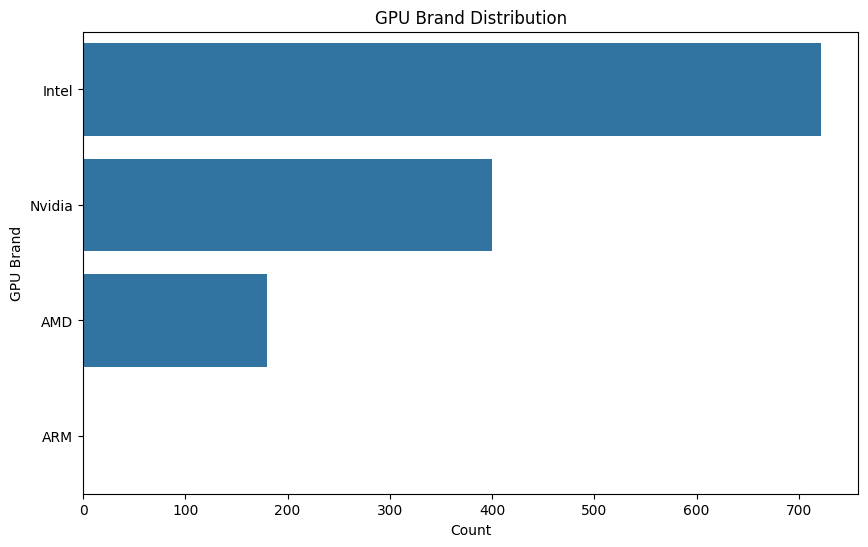

In [50]:
# Visualize GPU brand distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Gpu_Brand', order=df['Gpu_Brand'].value_counts().index)
plt.title('GPU Brand Distribution')
plt.xlabel('Count')
plt.ylabel('GPU Brand')
plt.show()

In [51]:
# Create GPU type
def get_gpu_type(gpu):
    if 'Intel' in gpu:
        return 'Integrated'
    else:
        return 'Dedicated'

df['Gpu_Type'] = df['Gpu'].apply(get_gpu_type)

# Count GPU type
df['Gpu_Type'].value_counts()

Integrated    722
Dedicated     581
Name: Gpu_Type, dtype: int64

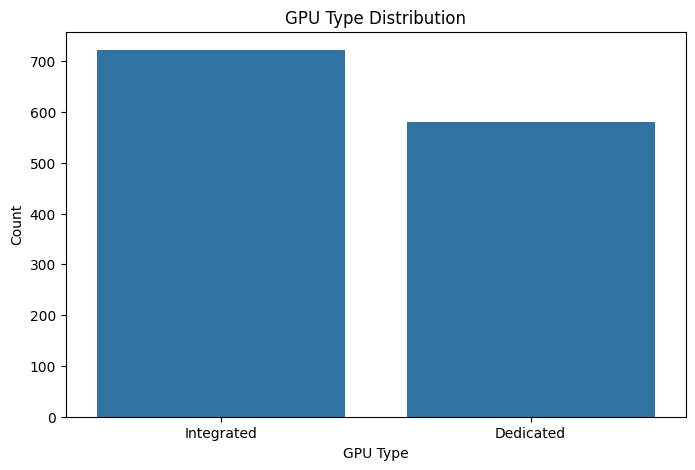

In [52]:
# Visualize GPU type distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gpu_Type', order=df['Gpu_Type'].value_counts().index)
plt.title('GPU Type Distribution')
plt.xlabel('GPU Type')
plt.ylabel('Count')
plt.show()

In [53]:
# Average price by GPU type
gpu_type_price = df.groupby('Gpu_Type')['Price_euros'].mean().sort_values(ascending=False)

gpu_type_price

Gpu_Type
Dedicated     1267.169157
Integrated    1008.225582
Name: Price_euros, dtype: float64

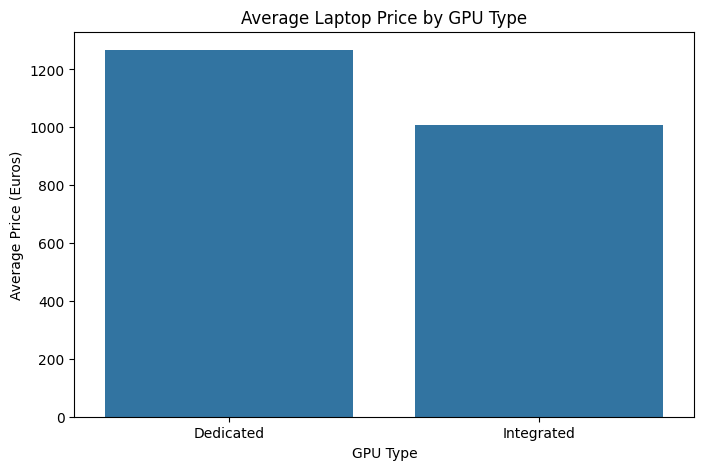

In [54]:
# Visualize average price by GPU type
plt.figure(figsize=(8, 5))
sns.barplot(x=gpu_type_price.index, y=gpu_type_price.values)
plt.title('Average Laptop Price by GPU Type')
plt.xlabel('GPU Type')
plt.ylabel('Average Price (Euros)')
plt.show()

## Storage Analysis

In [55]:
# Create storage type
def get_storage_type(memory):
    if 'SSD' in memory and 'HDD' in memory:
        return 'SSD + HDD'
    elif 'SSD' in memory:
        return 'SSD'
    elif 'HDD' in memory:
        return 'HDD'
    elif 'Flash Storage' in memory:
        return 'Flash Storage'
    elif 'Hybrid' in memory:
        return 'Hybrid'
    else:
        return 'Other'

df['Storage_Type'] = df['Memory'].apply(get_storage_type)

# Count storage type
df['Storage_Type'].value_counts()

SSD              643
HDD              376
SSD + HDD        200
Flash Storage     74
Hybrid            10
Name: Storage_Type, dtype: int64

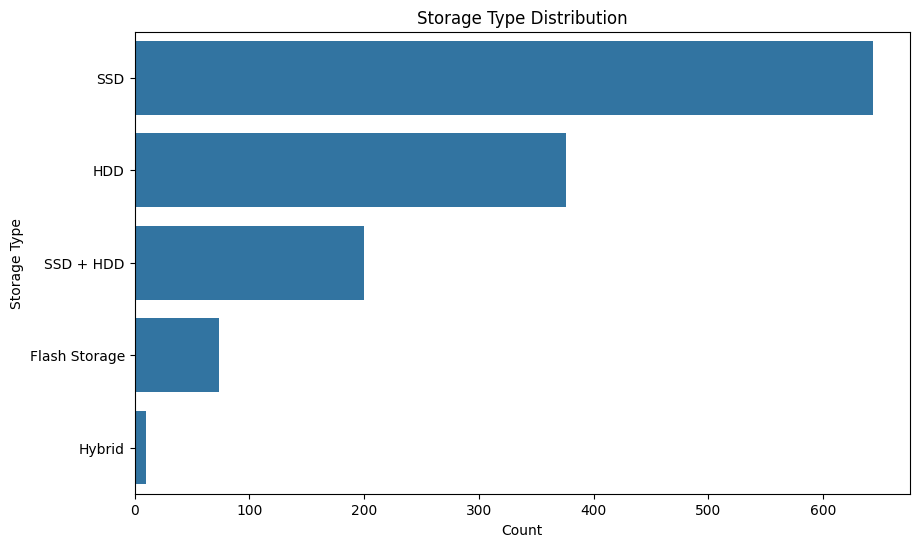

In [56]:
# Visualize storage type distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Storage_Type', order=df['Storage_Type'].value_counts().index)
plt.title('Storage Type Distribution')
plt.xlabel('Count')
plt.ylabel('Storage Type')
plt.show()

In [57]:
# Average price by storage type
storage_price = df.groupby('Storage_Type')['Price_euros'].mean().sort_values(ascending=False)

storage_price

Storage_Type
SSD + HDD        1613.456450
SSD              1318.908429
Hybrid            810.746000
HDD               658.855479
Flash Storage     507.805676
Name: Price_euros, dtype: float64

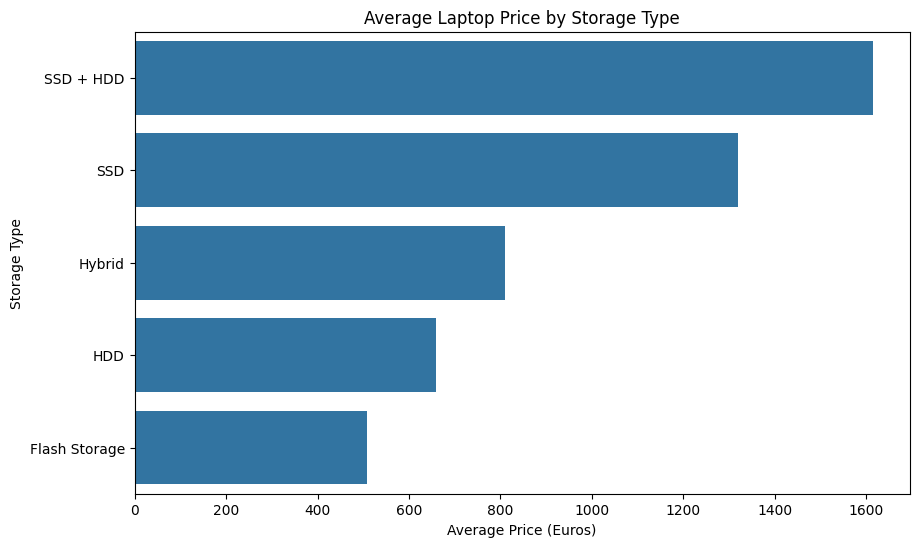

In [58]:
# Visualize average price by storage type
plt.figure(figsize=(10, 6))
sns.barplot(x=storage_price.values, y=storage_price.index)
plt.title('Average Laptop Price by Storage Type')
plt.xlabel('Average Price (Euros)')
plt.ylabel('Storage Type')
plt.show()

## Screen & Display Analysis

In [59]:
# Function to detect touchscreen feature
def detect_touchscreen(screen_resolution):
    if 'Touchscreen' in screen_resolution:
        return 'Yes'
    else:
        return 'No'

# Function to detect IPS panel feature
def detect_ips_panel(screen_resolution):
    if 'IPS' in screen_resolution:
        return 'Yes'
    else:
        return 'No'

# Create touchscreen and IPS panel columns
df['Touchscreen'] = df['ScreenResolution'].apply(detect_touchscreen)
df['IPS_Panel'] = df['ScreenResolution'].apply(detect_ips_panel)

# Display the result
df[['ScreenResolution', 'Touchscreen', 'IPS_Panel']].head()

,ScreenResolution,Touchscreen,IPS_Panel
0,IPS Panel Retina Display 2560x1600,No,Yes
1,1440x900,No,No
2,Full HD 1920x1080,No,No
3,IPS Panel Retina Display 2880x1800,No,Yes
4,IPS Panel Retina Display 2560x1600,No,Yes


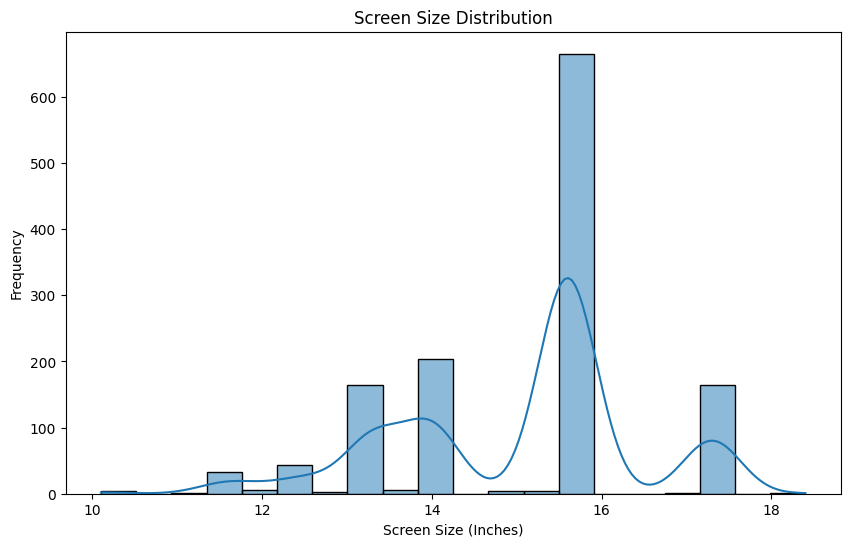

In [60]:
# Visualize screen size distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Inches'], bins=20, kde=True)
plt.title('Screen Size Distribution')
plt.xlabel('Screen Size (Inches)')
plt.ylabel('Frequency')
plt.show()

In [61]:
# Count touchscreen laptops
df['Touchscreen'].value_counts()

No     1111
Yes     192
Name: Touchscreen, dtype: int64

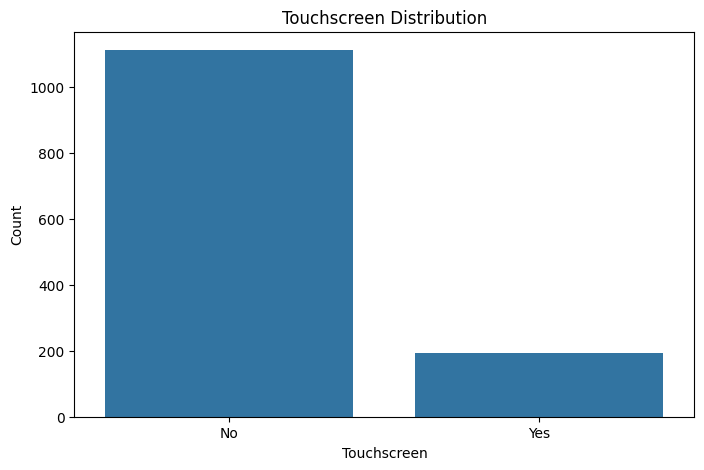

In [62]:
# Visualize touchscreen distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Touchscreen', order=df['Touchscreen'].value_counts().index)
plt.title('Touchscreen Distribution')
plt.xlabel('Touchscreen')
plt.ylabel('Count')
plt.show()

In [63]:
# Count IPS panel laptops
df['IPS_Panel'].value_counts()

No     938
Yes    365
Name: IPS_Panel, dtype: int64

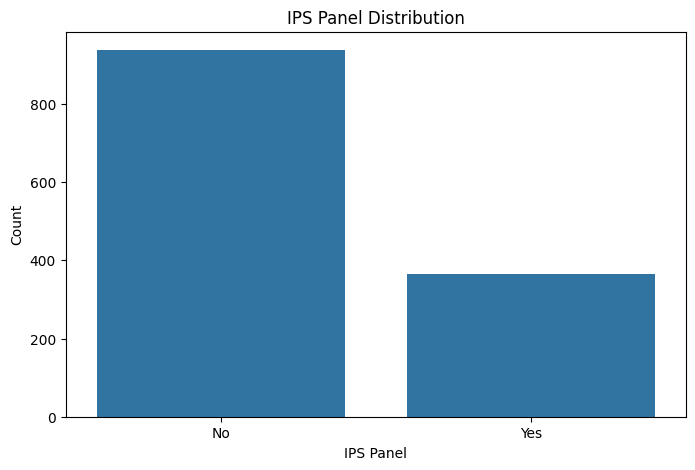

In [64]:
# Visualize IPS panel distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='IPS_Panel', order=df['IPS_Panel'].value_counts().index)
plt.title('IPS Panel Distribution')
plt.xlabel('IPS Panel')
plt.ylabel('Count')
plt.show()

In [65]:
# Average price by touchscreen feature
touch_price = df.groupby('Touchscreen')['Price_euros'].mean().sort_values(ascending=False)

touch_price

Touchscreen
Yes    1445.105208
No     1068.140369
Name: Price_euros, dtype: float64

In [66]:
# Average price by IPS panel feature
ips_price = df.groupby('IPS_Panel')['Price_euros'].mean().sort_values(ascending=False)

ips_price

IPS_Panel
Yes    1406.194027
No     1013.756215
Name: Price_euros, dtype: float64

## Weight Analysis

In [67]:
# Create weight column in numeric format
df['Weight_kg'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)

# Display descriptive statistics for weight
df['Weight_kg'].describe()

count    1303.000000
mean        2.038734
std         0.665475
min         0.690000
25%         1.500000
50%         2.040000
75%         2.300000
max         4.700000
Name: Weight_kg, dtype: float64

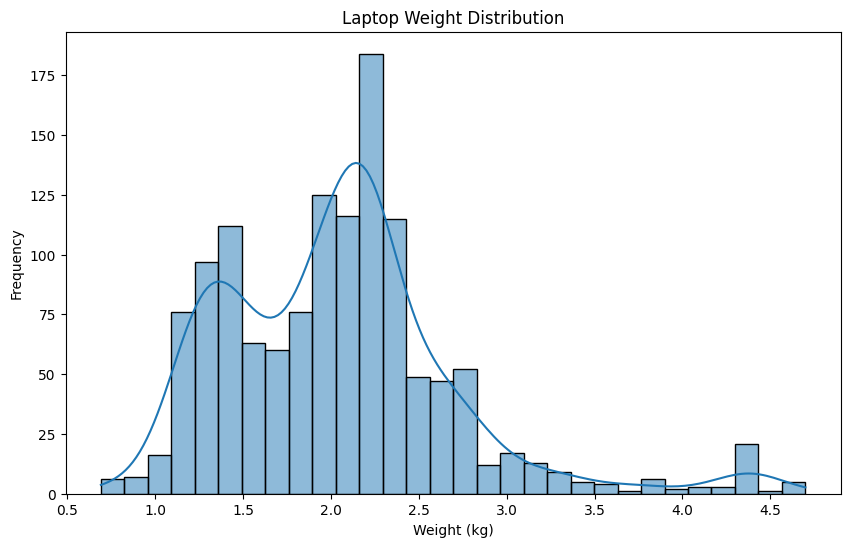

In [68]:
# Visualize weight distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Weight_kg'], bins=30, kde=True)
plt.title('Laptop Weight Distribution')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.show()

In [69]:
# Average weight by laptop type
type_weight = df.groupby('TypeName')['Weight_kg'].mean().sort_values()

type_weight

TypeName
Netbook               1.306000
Ultrabook             1.343204
2 in 1 Convertible    1.546620
Notebook              2.059395
Workstation           2.466552
Gaming                2.949761
Name: Weight_kg, dtype: float64

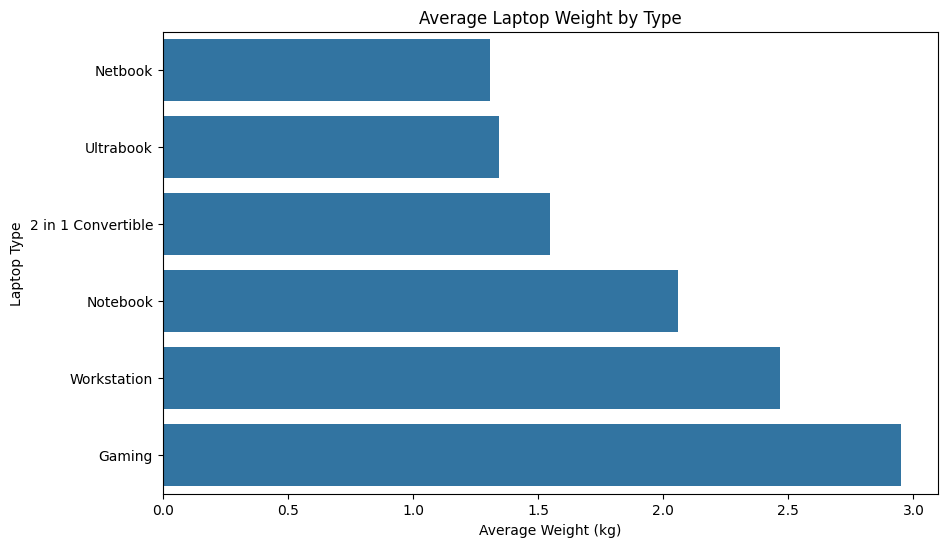

In [70]:
# Visualize average weight by laptop type
plt.figure(figsize=(10, 6))
sns.barplot(x=type_weight.values, y=type_weight.index)
plt.title('Average Laptop Weight by Type')
plt.xlabel('Average Weight (kg)')
plt.ylabel('Laptop Type')
plt.show()

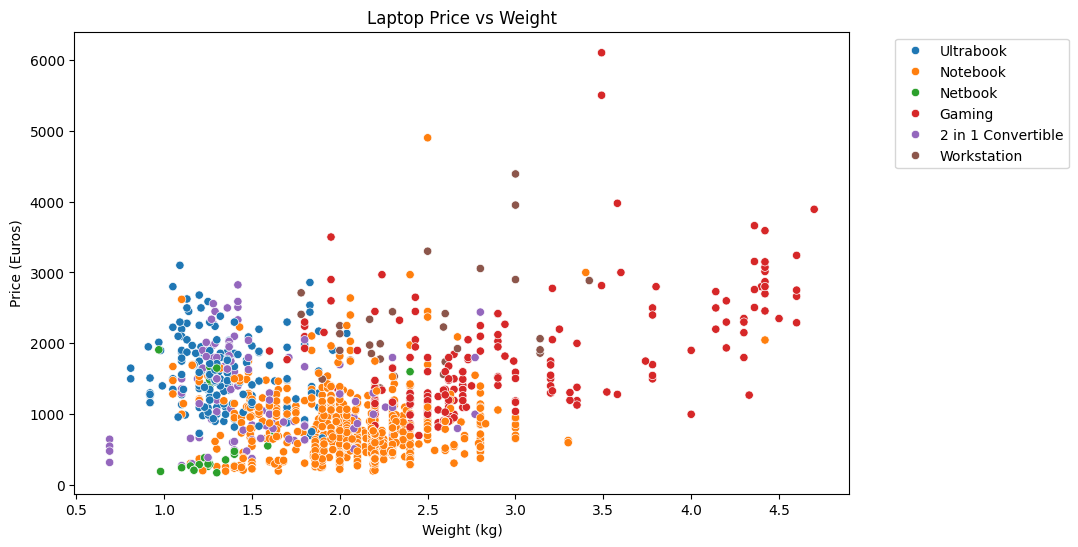

In [71]:
# Price vs weight
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Weight_kg', y='Price_euros', hue='TypeName')
plt.title('Laptop Price vs Weight')
plt.xlabel('Weight (kg)')
plt.ylabel('Price (Euros)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Correlation Analysis

In [81]:
# Select numerical columns for correlation analysis
numeric_cols = ['Inches', 'Ram_GB', 'Weight_kg', 'Price_euros']

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Display correlation matrix
corr_matrix

,Inches,Ram_GB,Weight_kg,Price_euros
Inches,1.000000,0.237993,0.827631,0.068197
Ram_GB,0.237993,1.000000,0.383874,0.743007
Weight_kg,0.827631,0.383874,1.000000,0.210370
Price_euros,0.068197,0.743007,0.210370,1.000000


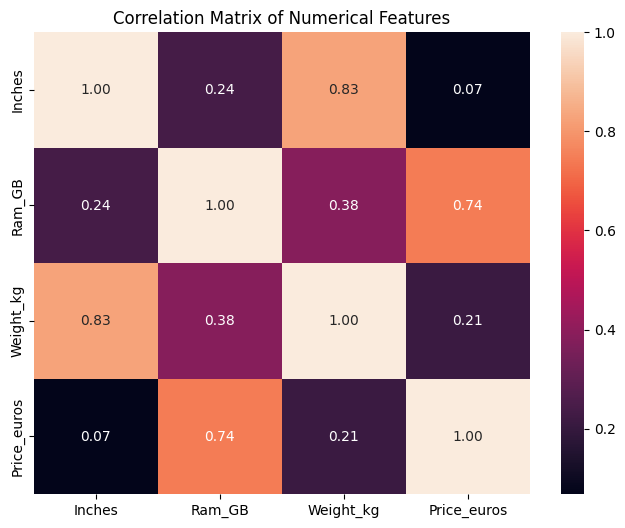

In [82]:
# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## EDA Summary

# Business Insight Summary

# Conclusion